# Preprocessing (CosmoMap PM-v1.4)

In [1]:
# Third-party imports,
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split

"""SPECIFICATIONS"""
SPEC = "IllustrisTNG_CV_z=0-0.5-1.0-1.5-2.0"
input1_UNITS = r"$M_{\odot}/h/(Mpc/h)^3$"
input2_UNITS = r"$km/s$"
target_UNITS = r"$K$"
input1_QUANTITY = "Dark Matter Density"
input2_QUANTITY = "Dark Matter Velocity"
target_QUANTITY = "Temperature"
MAPPING = "DMP-T"

# Loading Data

In [ ]:
def extract_images(data_list, redshifts, N_sims):

    # Creating empty array,
    extracted_list = []

    # Looping through all redshifts,
    for i, data in enumerate(data_list):

        # Consider a limited number of simulations,
        data_sample = data[0:N_sims]

        # Reshaping to only consider 2D slices,
        data_sample = data_sample.reshape(-1, data_sample.shape[2], data_sample.shape[3])

        # Appending,
        extracted_list.append(data_sample)

    # Stacking the images into a list,
    return np.concatenate(extracted_list, axis=0)

def create_redshift_labels(redshifts, N_sims):

    # Create empty array,
    images_redshifts = []

    # Looping over redshifts,
    for redshift in redshifts:

        # Creating redshift labels,
        redshift_array = redshift*np.ones(shape=(256*N_sims))

        # Appending,
        images_redshifts.append(redshift_array)

    return np.concatenate(images_redshifts, axis=0)

# Loading input data files,
X1_z00 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Mcdm_IllustrisTNG_CV_256_z=0.0.npy", mmap_mode='r')
X2_z00 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Vcdm_IllustrisTNG_CV_256_z=0.0.npy", mmap_mode='r')
X1_z05 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Mcdm_IllustrisTNG_CV_256_z=0.5.npy", mmap_mode='r')
X2_z05 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Vcdm_IllustrisTNG_CV_256_z=0.5.npy", mmap_mode='r')
X1_z10 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Mcdm_IllustrisTNG_CV_256_z=1.0.npy", mmap_mode='r')
X2_z10 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Vcdm_IllustrisTNG_CV_256_z=1.0.npy", mmap_mode='r')
X1_z15 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Mcdm_IllustrisTNG_CV_256_z=1.5.npy", mmap_mode='r')
X2_z15 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Vcdm_IllustrisTNG_CV_256_z=1.5.npy", mmap_mode='r')
X1_z20 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Mcdm_IllustrisTNG_CV_256_z=2.0.npy", mmap_mode='r')
X2_z20 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Vcdm_IllustrisTNG_CV_256_z=2.0.npy", mmap_mode='r')

# Loading target data files,

Y_z00 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_T_IllustrisTNG_CV_256_z=0.0.npy", mmap_mode='r')
Y_z05 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_T_IllustrisTNG_CV_256_z=0.5.npy", mmap_mode='r')
Y_z10 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_T_IllustrisTNG_CV_256_z=1.0.npy", mmap_mode='r')
Y_z15 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_T_IllustrisTNG_CV_256_z=1.5.npy", mmap_mode='r')
Y_z20 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_T_IllustrisTNG_CV_256_z=2.0.npy", mmap_mode='r')

"""
Y_z00 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Ne_IllustrisTNG_CV_256_z=0.0.npy", mmap_mode='r')
Y_z05 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Ne_IllustrisTNG_CV_256_z=0.5.npy", mmap_mode='r')
Y_z10 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Ne_IllustrisTNG_CV_256_z=1.0.npy", mmap_mode='r')
Y_z15 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Ne_IllustrisTNG_CV_256_z=1.5.npy", mmap_mode='r')
Y_z20 = np.load(r"..//CAMELs//IllustrisTNG_CV//Grids_Ne_IllustrisTNG_CV_256_z=2.0.npy", mmap_mode='r')
"""

"""SAMPLE DATA EXTRACTION"""

# PARAMETERS,
N_SIMS = 3
REDSHIFTS = [0, 0.5, 1, 1.5, 2]

# Extracting data,
X1 = extract_images(data_list=[X1_z00, X1_z05, X1_z10, X1_z15, X1_z20], redshifts=REDSHIFTS, N_sims=N_SIMS)
X2 = extract_images(data_list=[X2_z00, X2_z05, X2_z10, X2_z15, X2_z20], redshifts=REDSHIFTS, N_sims=N_SIMS)
Y = extract_images(data_list=[Y_z00, Y_z05, Y_z10, Y_z15, Y_z20], redshifts=REDSHIFTS, N_sims=N_SIMS)
redshift_labels = create_redshift_labels(redshifts=REDSHIFTS, N_sims=N_SIMS)

# Normalisation & Scaling

A Min-Max normalisation is used. In the code block below, we determine an arbitrary, but appropriate value for the minimum and maximum values of the dataset. For our mappings, it was found that $\rho_{min} = 10^{7}$, $\rho_{max} = 10^{17}$, $v_{min} = 0$, $v_{min} = 10^{4}$, $T_{min} = 10^{2}$, $T_{max} = 10^{9}$, $N_{e, min} = 10^{-9} $ and $N_{e, max} = 10^{-1}$.

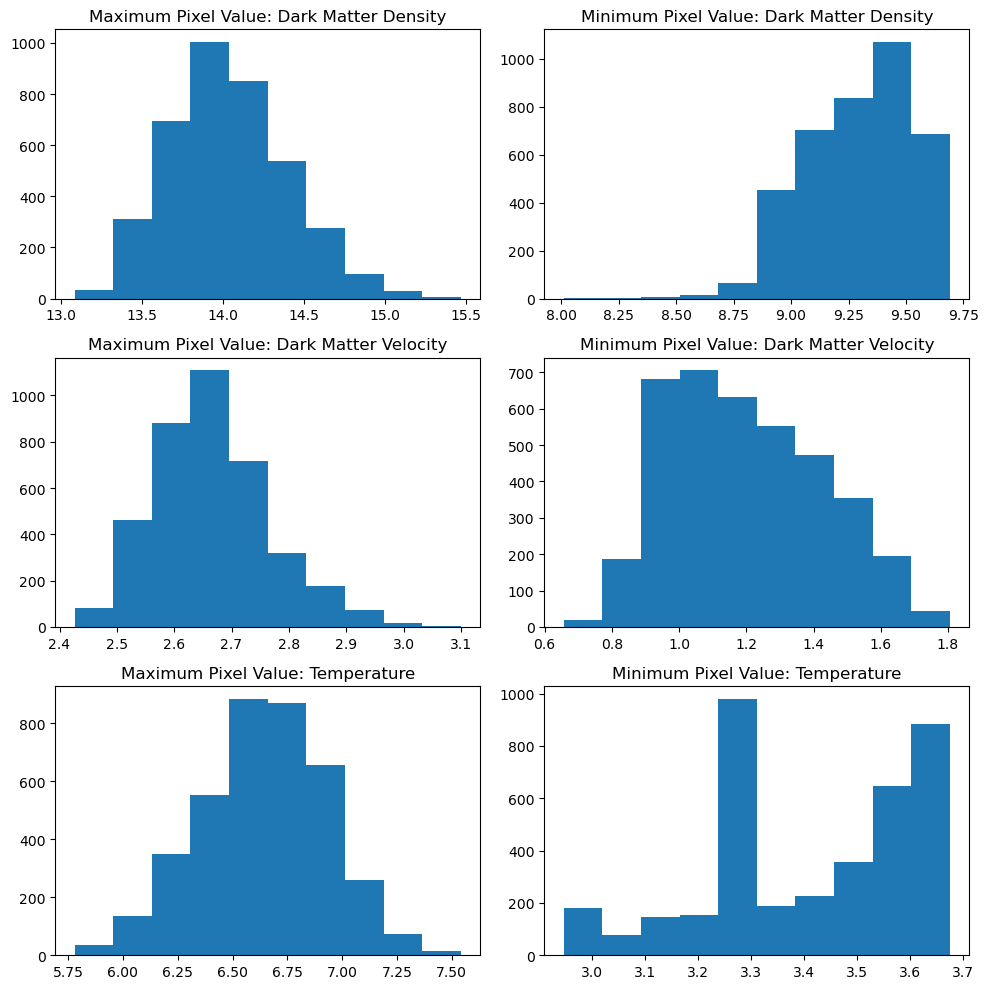

In [5]:
# Computing the maximum and minimum pixel value for each slice (image) for each simulation,
X1_max, X2_max, Y_max = np.amax(X1, axis = (1,2)), np.amax(X2, axis = (1,2)), np.amax(Y, axis = (1,2))
X1_min, X2_min, Y_min = np.amin(X1, axis = (1,2)), np.amin(X2, axis = (1,2)), np.amin(Y, axis = (1,2))

# Creating figure,
fig, axes = plt.subplots(3, 2, figsize = (10, 10))

# For the X1 data,
axes[0, 0].hist(np.log10(X1_max.flatten()))
axes[0, 0].set_title(f"Maximum Pixel Value: {input1_QUANTITY}")
axes[0, 1].hist(np.log10(X1_min.flatten()))
axes[0, 1].set_title(f"Minimum Pixel Value: {input1_QUANTITY}")

# For the X2 data,
axes[1, 0].hist(np.log10(X2_max.flatten()))
axes[1, 0].set_title(f"Maximum Pixel Value: {input2_QUANTITY}")
axes[1, 1].hist(np.log10(X2_min.flatten()))
axes[1, 1].set_title(f"Minimum Pixel Value: {input2_QUANTITY}")

# For the Y data,
axes[2, 0].hist(np.log10(Y_max.flatten()))
axes[2, 0].set_title(f"Maximum Pixel Value: {target_QUANTITY}")
axes[2, 1].hist(np.log10(Y_min.flatten()))
axes[2, 1].set_title(f"Minimum Pixel Value: {target_QUANTITY}")

# Display plot,
plt.tight_layout()
plt.show()

Performing the scaling and normalisation,

In [6]:
# Functions,
def MinMaxNorm(data, min_val, max_val):
    return (data - min_val)/(max_val - min_val)

# Applying logarithmic transform,
X1, X2, Y = np.log10(X1), np.log10(X2), np.log10(Y)

# Applying Min-Max normalisation,
X1_min, X1_max = 7, 17 #(DMD)
X2_min, X2_max = 0, 4 #(DMV)
Y_min, Y_max = 2, 9 #(DMP-T)
#Y_min, Y_max = -9, -1 #(DMP-Ne)

X1, X2, Y = MinMaxNorm(X1, X1_min, X1_max), MinMaxNorm(X2, X2_min, X2_max), MinMaxNorm(Y, Y_min, Y_max)

# Combining X1 and X2 into X (channel-first scheme used),
X = np.stack((X1, X2), axis=-1)

# Data Visualiser

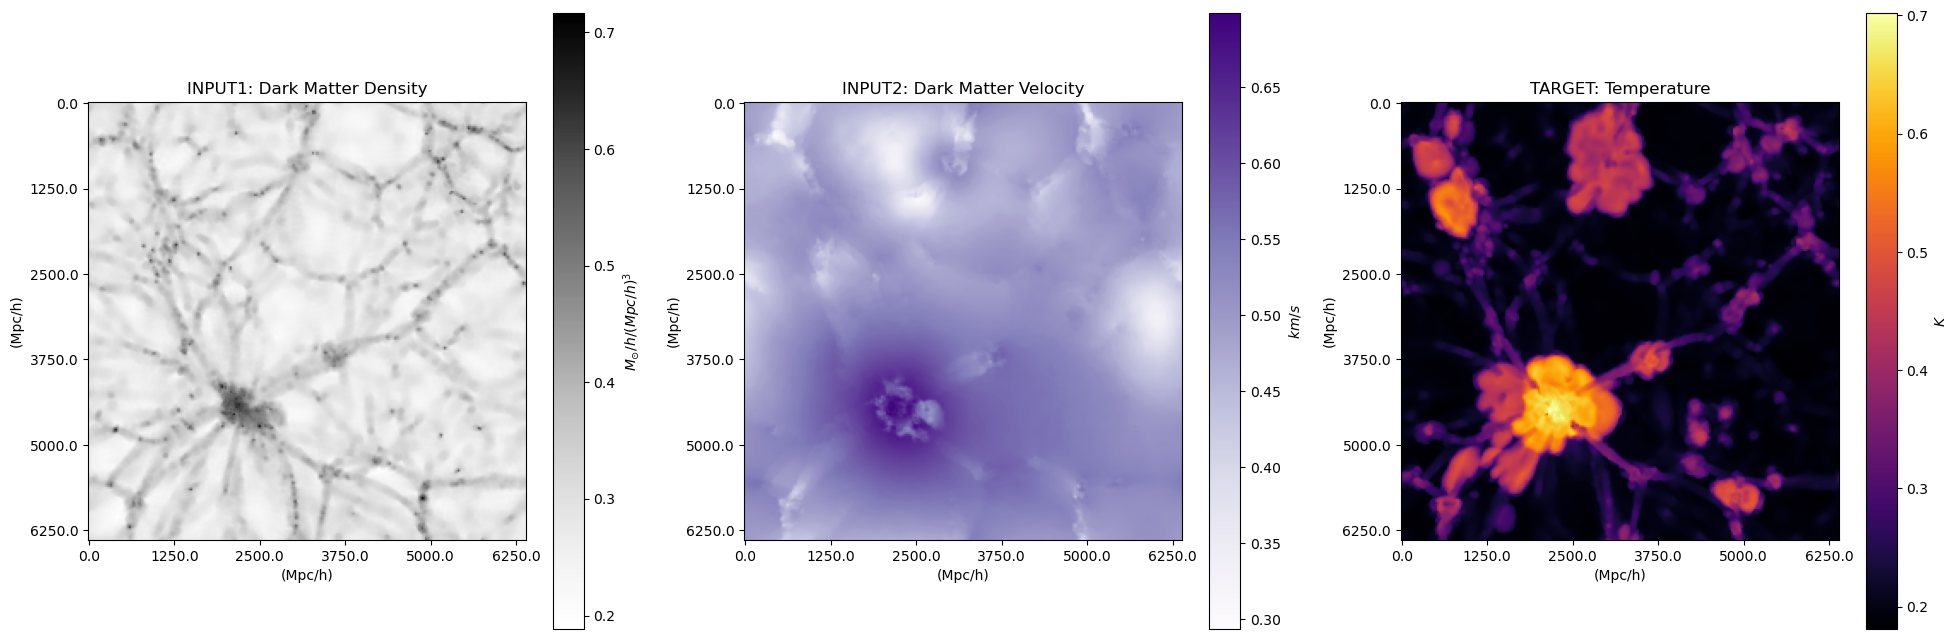

In [8]:
def plot_XYpair(image1, image2, image3):
    """Plots the ith slice of the a 3D grid."""

    # Creating figure, axis and image,
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    img1 = axes[0].imshow(image1, cmap="Greys")
    img2 = axes[1].imshow(image2, cmap="Purples")
    img3 = axes[2].imshow(image3, cmap="inferno")

    # Setting labels,
    axes[0].set_xlabel("(Mpc/h)")
    axes[0].set_ylabel("(Mpc/h)")
    axes[0].set_title("INPUT1: " + input1_QUANTITY)

    axes[1].set_xlabel("(Mpc/h)")
    axes[1].set_ylabel("(Mpc/h)")
    axes[1].set_title("INPUT2: " + input2_QUANTITY)

    axes[2].set_xlabel("(Mpc/h)")
    axes[2].set_ylabel("(Mpc/h)")
    axes[2].set_title("TARGET: " + target_QUANTITY)

    # Custom xtick and ytick labels,
    def custom_formatter(x, pos):
        return f'{x*25}'

    # Setting formatter,
    FORMATTER = FuncFormatter(custom_formatter)
    axes[0].xaxis.set_major_formatter(FORMATTER)
    axes[0].yaxis.set_major_formatter(FORMATTER)
    axes[1].xaxis.set_major_formatter(FORMATTER)
    axes[1].yaxis.set_major_formatter(FORMATTER)
    axes[2].xaxis.set_major_formatter(FORMATTER)
    axes[2].yaxis.set_major_formatter(FORMATTER)

    # Adding color bar,
    cbar1 = plt.colorbar(img1, ax=axes[0], orientation="vertical")
    cbar1.set_label(input1_UNITS)
    cbar2 = plt.colorbar(img2, ax=axes[1], orientation="vertical")
    cbar2.set_label(input2_UNITS)
    cbar3 = plt.colorbar(img3, ax=axes[2], orientation="vertical")
    cbar3.set_label(target_UNITS)

    # Showing plot,
    plt.show()

"""VISUALISATION"""
i = 0
plot_XYpair(np.transpose(X[i], (2, 0, 1))[0], np.transpose(X[i], (2, 0, 1))[1], Y[i])

# Stage 2 - Training, Testing and Validation Split

In [9]:
# Defining the split,
TRAIN_PROP = 0.80
VALIDATION_PROP = 0.025
TEST_PROP = 0.175
RANDOM_STATE = 42

# Creating explicit indices,
data_length = X.shape[0]
data_indices = np.arange(start = 0, stop = data_length, step = 1)

# Shuffling the indices,
np.random.shuffle(data_indices)

# Split indices into train and temp (val+test),
train_indices, temp_indices = train_test_split(data_indices, test_size = (VALIDATION_PROP + TEST_PROP), random_state = RANDOM_STATE)

# Further split temp into validation and test,
val_indices, test_indices = train_test_split(temp_indices, test_size = (TEST_PROP/(VALIDATION_PROP + TEST_PROP)), random_state = RANDOM_STATE)

# Creating training, testing and validation data,
X_train, Y_train, redshifts_train = X[train_indices], Y[train_indices], redshift_labels[train_indices]
X_test, Y_test, redshifts_test = X[test_indices], Y[test_indices], redshift_labels[test_indices]
X_val, Y_val, redshifts_val = X[val_indices], Y[val_indices], redshift_labels[val_indices]

# Stage 3 - Create TF Datasets

In [10]:
# Functions,
def serialise_example(x, y, θ_spec):
    """Serialises an (X,Y) pair for effficient storage."""
    feature = {
        "X_data": tf.train.Feature(float_list=tf.train.FloatList(value=x.flatten())),
        "Y_data": tf.train.Feature(float_list=tf.train.FloatList(value=y.flatten())),
        "θ_spec": tf.train.Feature(float_list=tf.train.FloatList(value=θ_spec.flatten())),
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

def save_to_tfrecord(X, Y, θ_spec, filename):
    """Write the dataset to a file on the disk."""
    with tf.io.TFRecordWriter(filename) as writer:
        for i in range(len(X)):
            example = serialise_example(X[i], Y[i], θ_spec[i])
            writer.write(example)
    print(f"Saved: {filename}")

# Saving to dataset to record files,
save_to_tfrecord(X_train, Y_train, redshifts_train, f"training_dataset({MAPPING}).tfrecord")
save_to_tfrecord(X_test, Y_test, redshifts_test, f"testing_dataset({MAPPING}).tfrecord")
save_to_tfrecord(X_val, Y_val, redshifts_test, f"validation_dataset({MAPPING}).tfrecord")

Saved: training_dataset(DMP-T).tfrecord
Saved: testing_dataset(DMP-T).tfrecord
Saved: validation_dataset(DMP-T).tfrecord
